# Day 07 — Seismic Attributes using Bruges

## Overview
In this session I explored **seismic attribute analysis using the Bruges Python library**.  
Seismic attributes help highlight geological features such as **faults, stratigraphic boundaries, and reservoir properties**.

For this exercise, a **small subset of the F3 seismic dataset** was used.

Attributes computed:

- Envelope (Reflection Strength / Instantaneous Amplitude)
- Instantaneous Phase
- Instantaneous Frequency
- Similarity (Semblance)
- Window-based attributes

---




In [1]:
import numpy as np 
import bruges as bg


In [ ]:
seismic=np.load()

Opening SEG-Y file...
Number of traces: 112875
Samples per trace: 227
SEG-Y data loaded
Saved: seismic.npy
Loaded shape: (112875, 227)


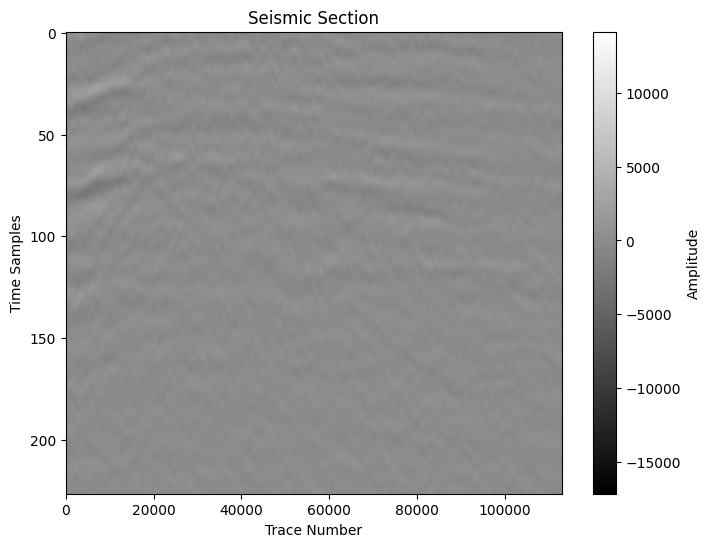

Conversion completed.


In [3]:
# ==========================================
# SEG-Y → NumPy (.npy) Conversion Script
# ==========================================

# Install segyio if not installed
try:
    import segyio
except ImportError:
    !pip install segyio
    import segyio

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Define SEG-Y file path
# -----------------------------
segy_file = "/home/ashraf/Downloads/ST8511r92.segy"   # change this to your SEG-Y file

print("Opening SEG-Y file...")

# -----------------------------
# 2. Load traces
# -----------------------------
with segyio.open(segy_file, "r", ignore_geometry=True) as f:

    n_traces = f.tracecount
    n_samples = len(f.samples)

    print("Number of traces:", n_traces)
    print("Samples per trace:", n_samples)

    # Create empty array
    seismic = np.zeros((n_traces, n_samples))

    # Read traces
    for i in range(n_traces):
        seismic[i] = f.trace[i]

print("SEG-Y data loaded")

# -----------------------------
# 3. Save NumPy file
# -----------------------------
output_file = "seismic.npy"

np.save(output_file, seismic)

print("Saved:", output_file)

# -----------------------------
# 4. Verify saved file
# -----------------------------
seismic_loaded = np.load(output_file)

print("Loaded shape:", seismic_loaded.shape)

# -----------------------------
# 5. Plot seismic section
# -----------------------------
plt.figure(figsize=(8,6))

plt.imshow(seismic_loaded.T,
           cmap="gray",
           aspect="auto")

plt.title("Seismic Section")
plt.xlabel("Trace Number")
plt.ylabel("Time Samples")

plt.colorbar(label="Amplitude")

plt.show()

print("Conversion completed.")


In [2]:
import numpy as np 
seismic_npy=np.load("/home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/Data/156_iline.npy")
seismic_npy.shape

(227, 301)

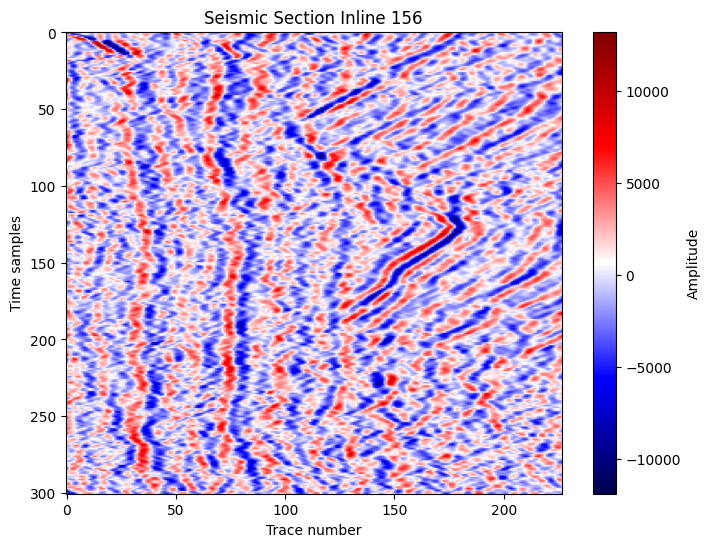

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(seismic_npy.T,
           cmap="seismic",
           aspect="auto")

plt.xlabel("Trace number")
plt.ylabel("Time samples")
plt.title("Seismic Section Inline 156")

plt.colorbar(label="Amplitude")

plt.show()


# Complex trace attributes

# What is the Envelope Attribute?

The **Envelope** represents the **instantaneous amplitude of a seismic signal**.

Instead of looking at positive and negative oscillations of the seismic trace, the envelope captures the **overall signal energy at each time sample**.

Mathematically, if a seismic trace is:

s(t)

and its **Hilbert Transform** is:

ŝ(t)

then the **Envelope** is given by:

Envelope(t) = √( s(t)² + ŝ(t)² )

Where:

- **s(t)** → original seismic trace  
- **ŝ(t)** → Hilbert transform of the trace  

The envelope is **always positive**, making it easier to interpret reflection strength.

---

# Why Envelope Attribute is Important

The envelope attribute is widely used in **seismic interpretation workflows** because it highlights **reflection energy**.

It is useful for identifying:

- **Bright spots** (possible hydrocarbon indicators)
- **Fault zones**
- **Stratigraphic channels**
- **Thin-bed reflections**
- **Reservoir boundaries**

Compared to raw seismic amplitude, the envelope makes **strong reflectors more visible**.

---

# Envelope Attribute Using Bruges

The **Bruges library** provides a convenient function to compute the envelope attribute directly from seismic data.

```python
import bruges as bg
import matplotlib.pyplot as plt

# Compute envelope attribute
env = bg.attribute.envelope(seismic_npy)

# Visualize a seismic slice
plt.figure(figsize=(6,10))
plt.imshow(env[5].T, cmap="seismic", aspect="auto")

plt.title("Envelope Attribute")
plt.xlabel("Trace Number")
plt.ylabel("Time / Depth")

plt.show()

In [20]:
import bruges as bg
# Envelope attribute
env=bg.attribute.envelope(seismic_npy)
print("Shape of the seismic file:",seismic_npy.shape)
print("Shape of the envelope attribute:",env.shape)
print(env[5].shape)

Shape of the seismic file: (227, 301)
Shape of the envelope attribute: (227, 301)
(301,)


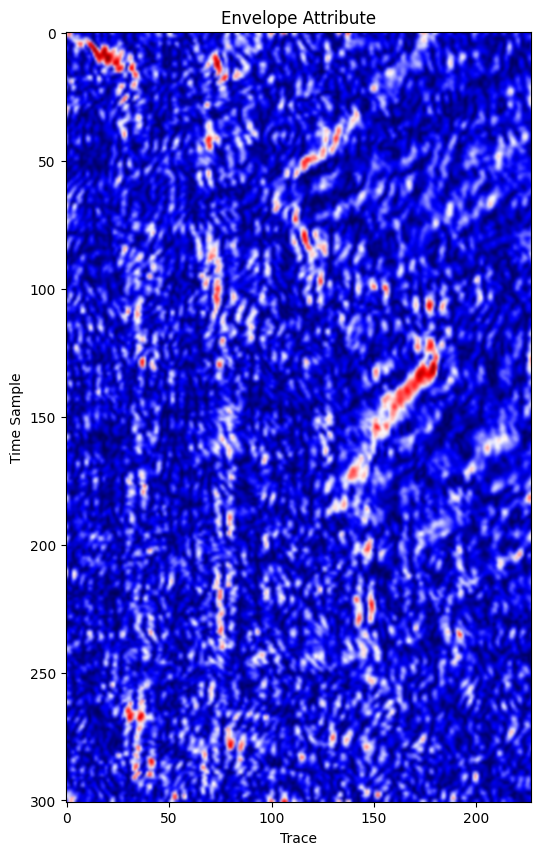

In [21]:
plt.figure(figsize=(6,10))
plt.imshow(env.T, cmap="seismic", aspect="auto", interpolation="bicubic")
plt.title("Envelope Attribute")
plt.xlabel("Trace")
plt.ylabel("Time Sample")
plt.show()

Text(0, 0.5, 'Amplitude')

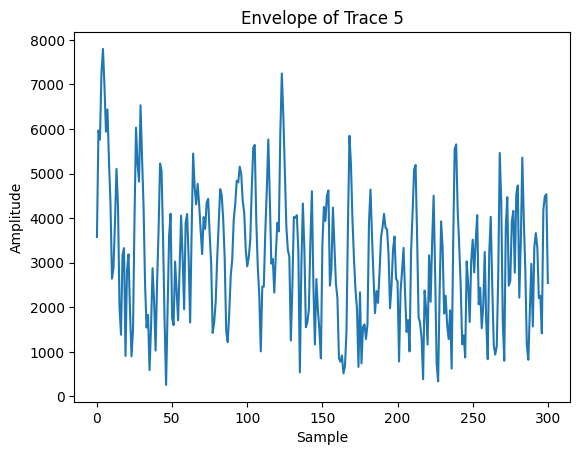

In [22]:
plt.plot(env[5])
plt.title("Envelope of Trace 5")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

# Instantaneous phase

In [ ]:
phase = bg.attribute.instantaneous_phase(seismic)

plt.figure(figsize=(6, 10))

